In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df_imdb=pd.read_csv('IMDB Dataset.csv')


In [3]:
df_imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
data_neg= df_imdb.iloc[:int(20000)]

In [5]:
data_neg

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
19995,"ok. for starters, taxi driver is amazing. this...",negative
19996,"It's sort of hard for me to say it, because I ...",negative
19997,I still liked it though. Warren Beatty is only...,positive
19998,We could still use Black Adder even today. Ima...,positive


In [6]:
df_imdb.value_counts()


review                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [7]:
df_imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [8]:
df_imdb['sentiment'].value_counts()

positive    25000
negative    25000
Name: sentiment, dtype: int64

In [9]:
df_imdb['review'].value_counts()

Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking around the corner to see what was coming up next. She is as down to earth and as personable as you get, like one of us which made the show all the more enjoyable. Special guests, who are friends as well made for a nice surprise too. Loved the 'first' theme and that the audience was invited to play along too. I must admit I was shocked to see her come in under her time limits on a few things, but she did it and by golly I'll be writing those recipes down. Saving time in the kitchen means more time with family. Those who haven't tuned in yet, find out what channel and the time, I assure you that you won't be disappointed.                                                                                                                                                                                                                

In [10]:
df_imdb.shape

(50000, 2)

In [11]:
df_imdb.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [12]:
df_imdb.isna()

,review,sentiment
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
49995,False,False
49996,False,False
49997,False,False
49998,False,False


In [13]:
df_imdb.dropna(inplace=True)


In [14]:
df_imdb


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [15]:
df_imdb.isnull().sum()


review       0
sentiment    0
dtype: int64

In [16]:
df_imdb.duplicated()


0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [17]:
df_imdb.duplicated().sum()


418

In [18]:
df_imdb.drop_duplicates(inplace=True)


In [19]:
df_imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [20]:
df_imdb['review'] = df_imdb['review'].apply(lambda x: x.lower())
df_imdb['review'].sample()


42196    for those expecting the cover art and story ou...
Name: review, dtype: object

In [21]:
df_imdb['review'].sample()


24433    i was interested in seeing this movie because ...
Name: review, dtype: object

In [22]:
import pandas as pd 
import numpy as np

import re
import string

import gensim
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from gensim.utils import simple_preprocess
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import pickle


In [23]:
def htmltags(txt):
    txt = re.sub(re.compile('<.*?>'), '', txt)
    return txt

In [24]:
df_imdb['review'].apply(htmltags)


0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 49582, dtype: object

In [25]:
sw = stopwords.words('english')
df_imdb['review'] = df_imdb['review'].apply(lambda x: [i for i in x.split() if i not in sw]).apply(lambda x: ' '.join(x))

df_imdb.sample()

,review,sentiment
47449,watching hilariously retro entertaining career...,positive


In [26]:
def removeUrl(text):
    p =re.compile(r"https?://\S+|www\.\S+")
    return p.sub(r'', text)

df_imdb['review'] = df_imdb['review'].apply(removeUrl)

In [27]:
punc= string.punctuation
punc

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [28]:
def removePunc(text):
    return text.translate(str.maketrans('','', punc))

df_imdb['review'] = df_imdb['review'].apply(removePunc)

In [29]:
df_imdb

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,positive
1,wonderful little production br br the filming ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive
...,...,...
49995,thought movie right good job creative original...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative


In [33]:
lemmatizer = WordNetLemmatizer()

def lem(txt):
    s = []
    sent = word_tokenize(txt)
    for word in sent:
        s.append(lemmatizer.lemmatize(word))

    return ' '.join(s)

In [34]:
df_imdb['review'] = df_imdb['review'].apply(lem)


In [35]:
comment = []
for doc in df_imdb['review']:
    raw = sent_tokenize(doc)
    for sent in raw:
        comment.append(simple_preprocess(sent))

In [36]:
model = gensim.models.Word2Vec(
    window = 10,
    min_count = 2
)

In [37]:
len(comment)


49582

In [38]:
model.build_vocab(comment)


In [39]:
model.train(comment, total_examples=model.corpus_count, epochs=model.epochs)


(28658633, 30843805)

In [40]:
len(model.wv.index_to_key)


70834

In [41]:
def document_vector(doc):
    new = [i for i in doc.split() if i in model.wv.index_to_key]
    return np.mean(model.wv[new], axis=0)

In [43]:
document_vector(df_imdb['review'].values[0])


array([ 0.5233702 ,  0.55304295, -0.22783914, -0.69823575,  0.38273358,
       -0.40563455,  0.74689287,  0.30981278, -0.09866709,  0.44757703,
        0.23573369, -0.11832362,  0.20155366,  0.21316129, -0.03233082,
       -0.15444331, -0.04875833,  0.269368  , -0.30742005, -0.64316446,
       -0.06496777, -0.17709586, -0.25302854,  0.10777079, -0.36978084,
       -0.30315682,  0.14138432, -0.6688384 ,  0.19910909, -0.03020439,
        0.61670583, -0.48842457,  0.1961672 , -0.5287501 ,  0.01394926,
        0.40780324,  0.22052363,  0.3612534 , -0.37556493, -0.20295252,
        0.03323444, -0.23531535,  0.15002128, -0.16308884,  0.3557698 ,
       -0.3049559 , -0.14121817, -0.11832718,  0.11045616, -0.19827709,
       -0.21198654, -0.42956412,  0.25715873, -0.24792576, -0.15663266,
       -0.2241165 ,  0.7019041 ,  0.11302177, -0.09860513, -0.1390984 ,
        0.07575577, -0.11804032,  0.04905731,  0.25393936, -0.49339724,
        0.52868193,  0.26381525,  0.2745941 , -0.14286804, -0.00

In [45]:
X = []
for i in tqdm(df_imdb['review'].values):
    X.append(document_vector(i))
    
len(X)

100%|██████████| 49582/49582 [57:06<00:00, 14.47it/s]  


49582

In [46]:
X = np.array(X)
X.shape

(49582, 100)

In [47]:
X[0]


array([ 0.5233702 ,  0.55304295, -0.22783914, -0.69823575,  0.38273358,
       -0.40563455,  0.74689287,  0.30981278, -0.09866709,  0.44757703,
        0.23573369, -0.11832362,  0.20155366,  0.21316129, -0.03233082,
       -0.15444331, -0.04875833,  0.269368  , -0.30742005, -0.64316446,
       -0.06496777, -0.17709586, -0.25302854,  0.10777079, -0.36978084,
       -0.30315682,  0.14138432, -0.6688384 ,  0.19910909, -0.03020439,
        0.61670583, -0.48842457,  0.1961672 , -0.5287501 ,  0.01394926,
        0.40780324,  0.22052363,  0.3612534 , -0.37556493, -0.20295252,
        0.03323444, -0.23531535,  0.15002128, -0.16308884,  0.3557698 ,
       -0.3049559 , -0.14121817, -0.11832718,  0.11045616, -0.19827709,
       -0.21198654, -0.42956412,  0.25715873, -0.24792576, -0.15663266,
       -0.2241165 ,  0.7019041 ,  0.11302177, -0.09860513, -0.1390984 ,
        0.07575577, -0.11804032,  0.04905731,  0.25393936, -0.49339724,
        0.52868193,  0.26381525,  0.2745941 , -0.14286804, -0.00

In [48]:
en = LabelEncoder()
y = en.fit_transform(df_imdb['sentiment'])
y

array([1, 1, 1, ..., 0, 0, 0])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)


In [51]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)


LogisticRegression()

In [52]:
y_pred=lr.predict(X_test)
print(y_pred)

[0 0 0 ... 1 0 0]


In [53]:
print("Predicted Values:")
print(y_pred)
print("Actual Values:")
print(y_test)


Predicted Values:
[0 0 0 ... 1 0 0]
Actual Values:
[1 0 0 ... 1 1 0]


In [54]:
df2=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
df2.head(30)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,0


In [55]:
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(y_test, y_pred)

In [56]:
print(cm)


[[4244  696]
 [ 606 4371]]


In [57]:
print("accuracy",metrics.accuracy_score(y_test,y_pred))


accuracy 0.8687102954522538


In [58]:
cf=confusion_matrix(y_test,y_pred)
print(cf)
print("Classification Report for Testing Dataset:")
print(classification_report(y_test,y_pred))

[[4244  696]
 [ 606 4371]]
Classification Report for Testing Dataset:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4940
           1       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



<Axes: >

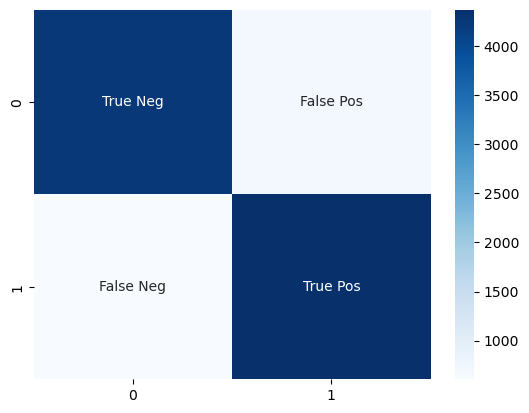

In [59]:
labels = ['True Neg','False Pos','False Neg','True Pos']
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf, annot=labels, fmt='', cmap='Blues')

In [61]:
df_imdb['sentiment'].head(5)


0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

In [69]:
pip install Wordcloud


  Obtaining dependency information for Wordcloud from https://files.pythonhosted.org/packages/00/09/abb305dce85911b8fba382926cfc57f2f257729e25937fdcc63f3a1a67f9/wordcloud-1.9.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/299.9 kB ? eta -:--:--
   --- ----------------------------------- 30.7/299.9 kB 325.1 kB/s eta 0:00:01
   --- ----------------------------------- 30.7/299.9 kB 325.1 kB/s eta 0:00:01
   --- ----------------------------------- 30.7/299.9 kB 325.1 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/299.9 kB 130.7 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/299.9 kB 172.4 kB/s eta 0:00:02
   ---------- ---------------------------- 81.9/299.9 kB 229.0 kB/s eta 0:00:01
   ---------- ---------------------------- 81.9/299.9 kB 229.0 kB/s eta 0:00:01
   ---------- ---------------------------- 81.9/299.9 kB 229.0 kB/s eta 0:00:01
   -

In [71]:
 from wordcloud import WordCloud

<function matplotlib.pyplot.show(close=None, block=None)>

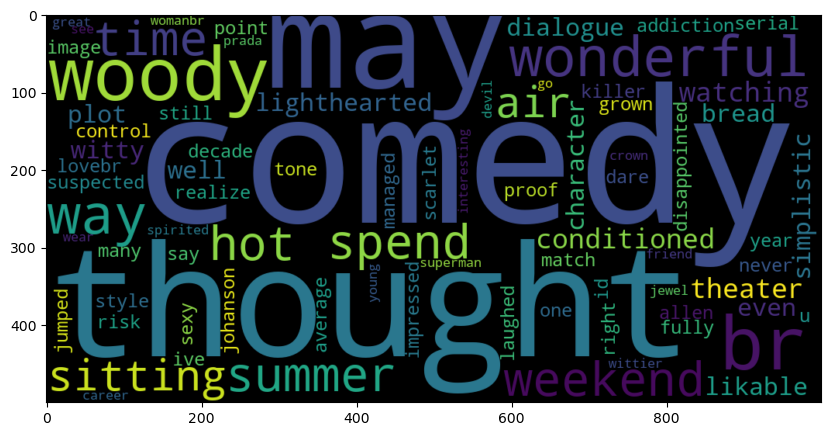

In [72]:
plt.figure(figsize=(10,10))
text=df_imdb["review"][2]
WC=WordCloud(width=1000,height=500,max_words=500,min_font_size=5)
words=WC.generate(text)
plt.imshow(words,interpolation='bilinear')
plt.show

#cloud of words for positive review

In [77]:
df_imdb['sentiment'].head(5)


0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

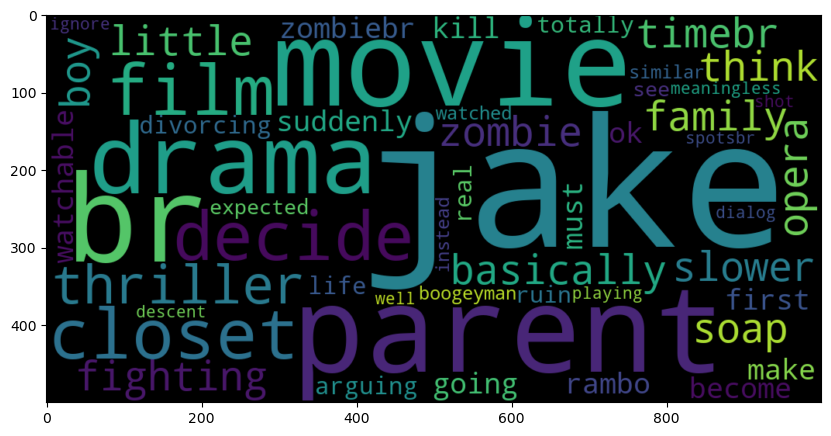

In [78]:
plt.figure(figsize=(10,10))
text=df_imdb["review"][3]
WC=WordCloud(width=1000,height=500,max_words=500,min_font_size=5)
words=WC.generate(text)
plt.imshow(words,interpolation='bilinear')
plt.show

#cloud of words for negative review 

In [ ]:
#Review is the independent variable